In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error



In [2]:
!pip install xlrd

In [3]:

df = pd.read_excel(r"C:\Users\Merutha sree\Downloads\concrete+compressive+strength\Concrete_Data.xls")

In [4]:
df.head()

,Cement (component 1)(kg in a m^3 mixture),Blast Furnace Slag (component 2)(kg in a m^3 mixture),Fly Ash (component 3)(kg in a m^3 mixture),Water (component 4)(kg in a m^3 mixture),Superplasticizer (component 5)(kg in a m^3 mixture),Coarse Aggregate (component 6)(kg in a m^3 mixture),Fine Aggregate (component 7)(kg in a m^3 mixture),Age (day),"Concrete compressive strength(MPa, megapascals)"
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.986111
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.887366
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.269535
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.052780
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.296075


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1030 entries, 0 to 1029
Data columns (total 9 columns):
 #   Column                                                 Non-Null Count  Dtype  
---  ------                                                 --------------  -----  
 0   Cement (component 1)(kg in a m^3 mixture)              1030 non-null   float64
 1   Blast Furnace Slag (component 2)(kg in a m^3 mixture)  1030 non-null   float64
 2   Fly Ash (component 3)(kg in a m^3 mixture)             1030 non-null   float64
 3   Water  (component 4)(kg in a m^3 mixture)              1030 non-null   float64
 4   Superplasticizer (component 5)(kg in a m^3 mixture)    1030 non-null   float64
 5   Coarse Aggregate  (component 6)(kg in a m^3 mixture)   1030 non-null   float64
 6   Fine Aggregate (component 7)(kg in a m^3 mixture)      1030 non-null   float64
 7   Age (day)                                              1030 non-null   int64  
 8   Concrete compressive strength(MPa, megapascals)  

In [6]:
df.shape

(1030, 9)

In [7]:
df.describe

<bound method NDFrame.describe of       Cement (component 1)(kg in a m^3 mixture)  \
0                                         540.0   
1                                         540.0   
2                                         332.5   
3                                         332.5   
4                                         198.6   
...                                         ...   
1025                                      276.4   
1026                                      322.2   
1027                                      148.5   
1028                                      159.1   
1029                                      260.9   

      Blast Furnace Slag (component 2)(kg in a m^3 mixture)  \
0                                                   0.0       
1                                                   0.0       
2                                                 142.5       
3                                                 142.5       
4                                     

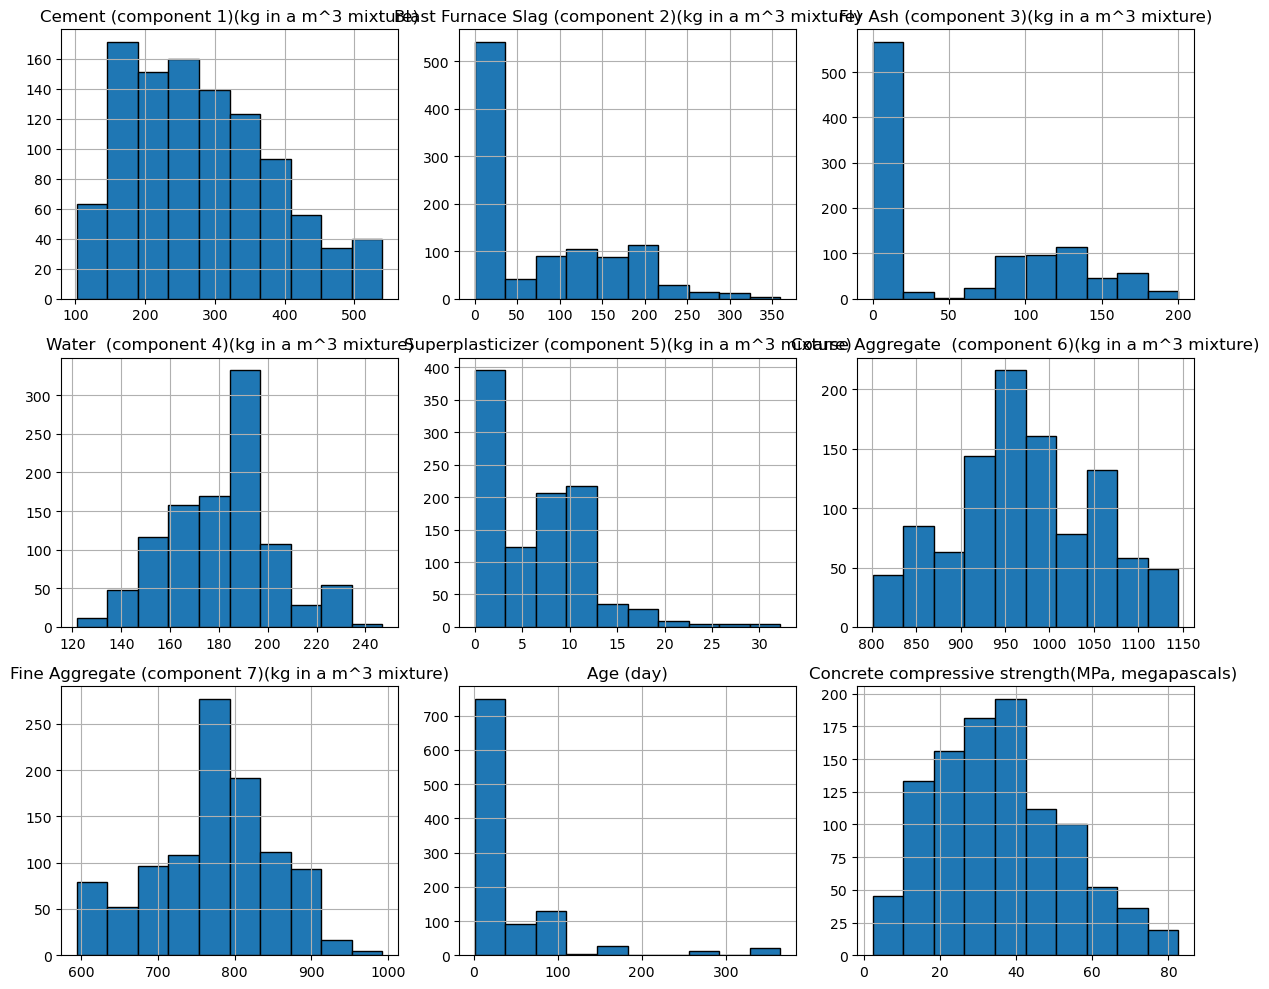

In [ ]:
df.hist(figsize=(12, 10), layout=(3,3), edgecolor='black')#visualization
plt.tight_layout()
plt.show()

In [9]:
df.isnull().sum()

Cement (component 1)(kg in a m^3 mixture)                0
Blast Furnace Slag (component 2)(kg in a m^3 mixture)    0
Fly Ash (component 3)(kg in a m^3 mixture)               0
Water  (component 4)(kg in a m^3 mixture)                0
Superplasticizer (component 5)(kg in a m^3 mixture)      0
Coarse Aggregate  (component 6)(kg in a m^3 mixture)     0
Fine Aggregate (component 7)(kg in a m^3 mixture)        0
Age (day)                                                0
Concrete compressive strength(MPa, megapascals)          0
dtype: int64

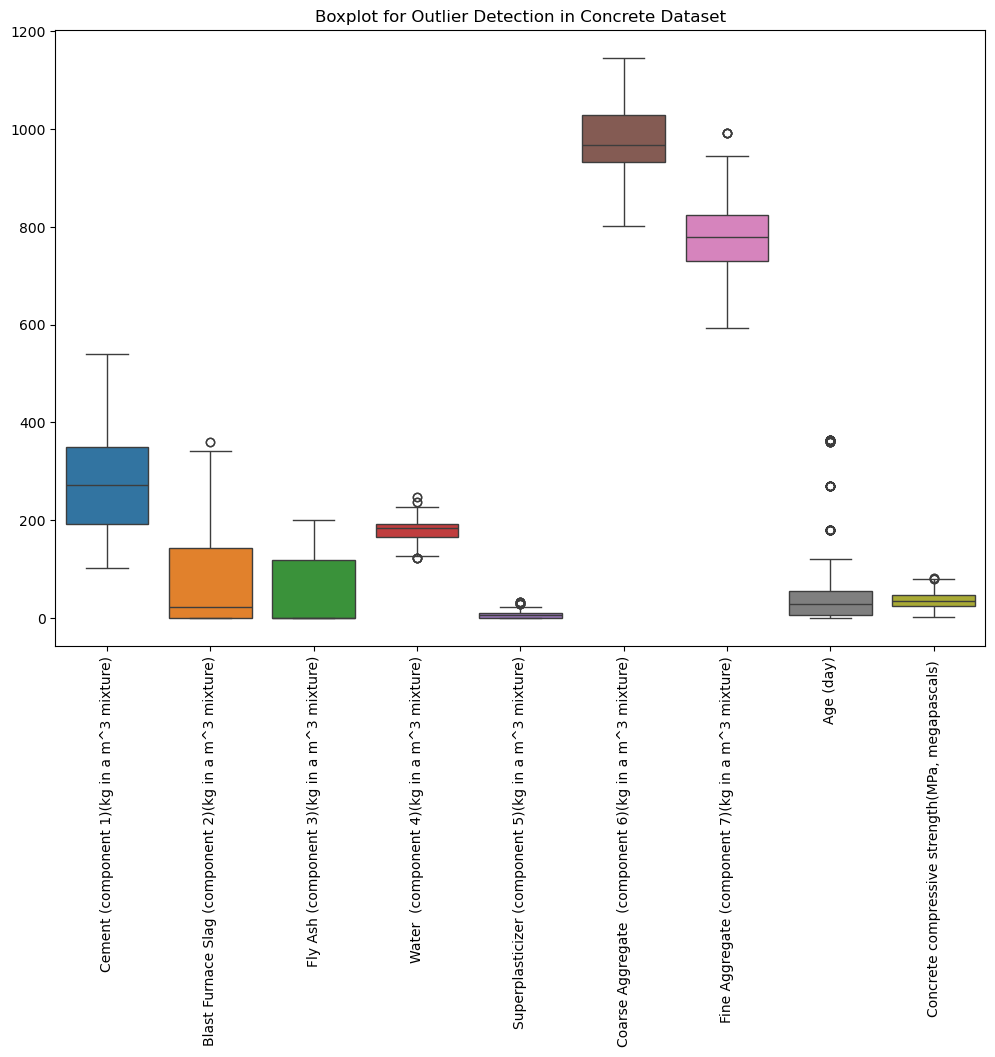

In [14]:
plt.figure(figsize=(12,8))
sns.boxplot(data=df)
plt.xticks(rotation=90)
plt.title("Boxplot for Outlier Detection in Concrete Dataset")
plt.show()

In [ ]:
Q1 = df.quantile(0.25)#outlier detection
Q3 = df.quantile(0.75)

IQR = Q3 - Q1

outliers = df[((df < (Q1 - 1.5 * IQR)) | (df > (Q3 + 1.5 * IQR)))]

print(outliers)

      Cement (component 1)(kg in a m^3 mixture)  \
0                                           NaN   
1                                           NaN   
2                                           NaN   
3                                           NaN   
4                                           NaN   
...                                         ...   
1025                                        NaN   
1026                                        NaN   
1027                                        NaN   
1028                                        NaN   
1029                                        NaN   

      Blast Furnace Slag (component 2)(kg in a m^3 mixture)  \
0                                                   NaN       
1                                                   NaN       
2                                                   NaN       
3                                                   NaN       
4                                                   NaN       
...      

In [12]:
df_clean = df[~((df < (Q1 - 1.5 * IQR)) | (df > (Q3 + 1.5 * IQR))).any(axis=1)]

print("Original Shape:", df.shape)
print("After Removing Outliers:", df_clean.shape)

Original Shape: (1030, 9)
After Removing Outliers: (941, 9)


In [ ]:

X = df.iloc[:, :-1]#feature scaling
y = df.iloc[:, -1]

In [19]:


X_value= df.iloc[:, [0]] 
y_value = df.iloc[:, -1]

In [23]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(X_value, y_value, test_size=0.2, random_state=42)

s = LinearRegression()
s.fit(X_train_s, y_train_s)



LinearRegression()

In [24]:
y_pred_s = s.predict(X_test_s)

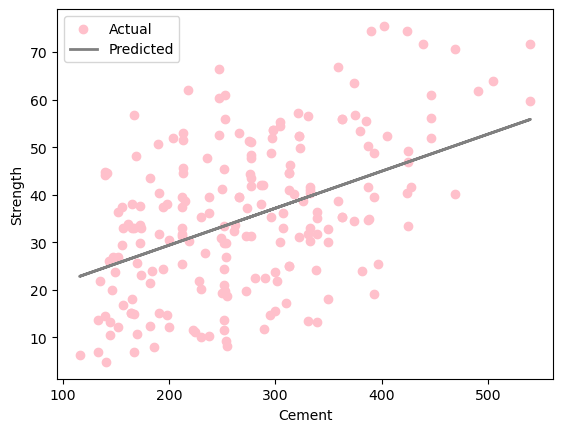

In [26]:
plt.scatter(X_test_s, y_test_s, color='pink', label='Actual')
plt.plot(X_test_s, y_pred_s, color='grey', linewidth=2, label='Predicted')
plt.xlabel('Cement')
plt.ylabel('Strength')
plt.legend()
plt.show()

In [27]:
print("Simple Linear Regression Metrics:")
print(f"R2 Score: {r2_score(y_test_s, y_pred_s)}")
print(f"MAE: {mean_absolute_error(y_test_s, y_pred_s)}")
print(f"MSE: {mean_squared_error(y_test_s, y_pred_s)}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test_s, y_pred_s))}")

Simple Linear Regression Metrics:
R2 Score: 0.25183140674244187
MAE: 11.555820769998833
MSE: 192.78889718821986
RMSE: 13.884844154264744


In [ ]:

#Muliple linear regression
X_multi = X_scaled
y_multi = y


In [29]:
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(X_multi, y_multi, test_size=0.2, random_state=42)

In [30]:
model_m = LinearRegression()
model_m.fit(X_train_m, y_train_m)

LinearRegression()

In [31]:

y_pred_m = model_m.predict(X_test_m)

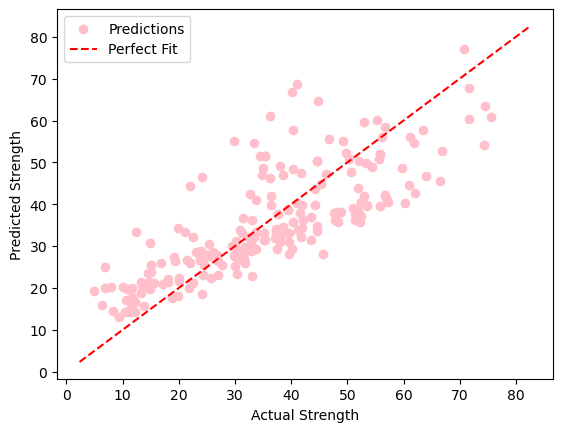

In [32]:

plt.scatter(y_test_m, y_pred_m, color='pink', label='Predictions')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', label='Perfect Fit')
plt.xlabel('Actual Strength')
plt.ylabel('Predicted Strength')
plt.legend()
plt.show()

In [33]:
print("\nMultiple Linear Regression Metrics:")
print(f"R2 Score: {r2_score(y_test_m, y_pred_m)}")
print(f"MAE: {mean_absolute_error(y_test_m, y_pred_m)}")
print(f"MSE: {mean_squared_error(y_test_m, y_pred_m)}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test_m, y_pred_m))}")


Multiple Linear Regression Metrics:
R2 Score: 0.6275416055429018
MAE: 7.745392872421347
MSE: 95.97548435337711
RMSE: 9.796707832398448
